# Noise-correlation PSTHs by brain region and LDA-1 bin (clean, matched to ff_psth_ldabin)
Time-resolved within-region mean spike-count correlation per session x region (condition-adjusted: stimulus side x contrast means removed before correlating), then averaged across sessions within each LDA-1 bin. Same controls as ff_psth_ldabin: causal window, per-session trial subsampling (balancing) with repeats, optional neuron cap, region selection, autoscaled y.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from scipy.ndimage import uniform_filter1d
from iblatlas.regions import BrainRegions
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [7]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
clustering_dir = prefix + 'clustering/'

REGION_LEVEL = 'beryl'    # 'cosmos' | 'beryl'
DROP = ['root', 'void']
WIN_BINS = 5               # sliding-window width (bins) for the spike-count correlation
SMOOTH_MODE = 'causal'     # 'causal' (only bins <= t) or 'centered'
MIN_NEURONS = 15
N_BINS = 7                 # LDA-1 bins (lda['binned1'])
REMOVE_CONDITION = True    # subtract stimulus (side x contrast) means before correlating -> noise r_SC
BALANCE_SESSIONS = True    # subsample each session to a common trial count (uniform bias across bins)
SESSION_N_TARGET = 100     # complete trials per session when balancing (sessions with fewer are skipped)
N_SUBSAMPLE_REPEATS = 10   # average r_SC over this many random subsamples
N_NEURONS_CAP = None       # if int, subsample each region to this many neurons
SEED = 0
CORRECT_ONLY = True     # if True, use only correct trials

lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
lda['bin'] = lda['binned1'].cat.codes
bin_map = dict(zip(lda['session'], lda['bin']))
trials_df = pd.read_parquet(prefix + '4_mice/all_trials_04-05-2026')
correct_by_session = trials_df[trials_df['correct'] == 1.0].groupby('session')['trial_id'].apply(set).to_dict()
br = BrainRegions()
print(f"LDA sessions: {lda['session'].nunique()}, bins: {sorted(lda['bin'].unique())}")

LDA sessions: 248, bins: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]


## Compute one noise-correlation PSTH per session x region

In [8]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols]); T = len(tcols)

def smooth_time(A, W, mode):
    if mode == 'centered':
        return uniform_filter1d(A, W, axis=2, mode='nearest')
    c = np.cumsum(A, axis=2); out = np.empty_like(A)
    out[..., :W] = c[..., :W] / np.arange(1, W + 1)
    out[..., W:] = (c[..., W:] - c[..., :-W]) / W
    return out

def rsc_curve(A, cond=None):
    """A: neurons x trials x T (complete trials). Mean off-diagonal correlation per time bin,
    optionally after removing stimulus-condition means (noise correlation)."""
    R = A.astype(float)
    if REMOVE_CONDITION and cond is not None:
        R = R.copy()
        for cc in pd.unique(cond):
            ci = np.where(cond == cc)[0]
            R[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)
    mean = np.nanmean(R, axis=1, keepdims=True); std = np.nanstd(R, axis=1, ddof=1, keepdims=True)
    Z = (R - mean) / std
    Z[~np.isfinite(Z)] = np.nan
    nL = R.shape[1]
    s = np.nansum(Z, axis=0); sumsq = np.nansum(s ** 2, axis=0)
    nvalid = ((np.isfinite(std[:, 0, :])) & (std[:, 0, :] > 0)).sum(0).astype(float)
    with np.errstate(invalid='ignore', divide='ignore'):
        off = (sumsq / (nL - 1) - nvalid) / (nvalid * (nvalid - 1))
    off[nvalid < 2] = np.nan
    return off

rng = np.random.default_rng(SEED)
records = []
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        if session not in bin_map: continue
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}
        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values

        na = d.groupby('nuid')['area'].first().reindex(neurons)
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values
        cond_all = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials).values
        corr_set = correct_by_session.get(session, set())
        correct_mask = np.array([t in corr_set for t in trials]) if CORRECT_ONLY else np.ones(len(trials), dtype=bool)

        for region in pd.unique(neu_area):
            if region is None or (isinstance(region, float) and np.isnan(region)): continue
            ni = np.where(neu_area == region)[0]
            if len(ni) < MIN_NEURONS: continue
            if N_NEURONS_CAP and len(ni) > N_NEURONS_CAP:
                ni = rng.choice(ni, N_NEURONS_CAP, replace=False)
            Asub = A[ni]
            complete = ~np.isnan(Asub).any(axis=(0, 2))          # r_SC is pairwise -> need shared trials
            comp_idx = np.where(complete & correct_mask)[0]   # correct-only if toggled
            Aw = smooth_time(Asub[:, comp_idx, :], WIN_BINS, SMOOTH_MODE)
            conds = cond_all[comp_idx]
            if BALANCE_SESSIONS:
                if len(comp_idx) < SESSION_N_TARGET: continue
                reps = []
                for _ in range(N_SUBSAMPLE_REPEATS):
                    s = rng.choice(len(comp_idx), SESSION_N_TARGET, replace=False)
                    reps.append(rsc_curve(Aw[:, s, :], conds[s]))
                curve = np.nanmean(reps, axis=0); n_used = SESSION_N_TARGET
            else:
                if len(comp_idx) < MIN_NEURONS: continue
                curve = rsc_curve(Aw, conds); n_used = len(comp_idx)
            records.append(dict(session=session, region=region, bin=bin_map[session],
                                n_neurons=len(ni), n_trials=n_used, curve=curve))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

curves = pd.DataFrame(records)
print(f"Computed {len(curves)} session-region curves | {curves['session'].nunique()} sessions | "
      f"regions: {sorted(curves['region'].unique())}")

  100/380 files...
  200/380 files...
  300/380 files...
Computed 754 session-region curves | 219 sessions | regions: ['ACAd', 'ACAv', 'ACB', 'AId', 'AIp', 'AIv', 'AM', 'ANcr1', 'ANcr2', 'AON', 'APN', 'AV', 'BLA', 'BMA', 'BST', 'CA1', 'CA3', 'CEA', 'CENT2', 'CENT3', 'CL', 'CLA', 'COAa', 'COPY', 'CP', 'CS', 'CUL4 5', 'CUN', 'DCO', 'DEC', 'DG', 'DN', 'DP', 'DTN', 'ECT', 'ENTl', 'ENTm', 'EPd', 'EPv', 'Eth', 'FL', 'FN', 'FOTU', 'FRP', 'FS', 'GPe', 'GPi', 'GRN', 'HATA', 'IC', 'ICB', 'ILA', 'IP', 'IRN', 'LA', 'LAV', 'LD', 'LDT', 'LGd', 'LGv', 'LHA', 'LP', 'LPO', 'LSc', 'LSr', 'LSv', 'MARN', 'MD', 'MDRN', 'MEA', 'MG', 'MOB', 'MOp', 'MOs', 'MPO', 'MRN', 'MS', 'MV', 'NB', 'NDB', 'NI', 'NLL', 'NOD', 'NPC', 'NTS', 'ORBl', 'ORBm', 'ORBvl', 'OT', 'PAA', 'PAG', 'PAR', 'PARN', 'PB', 'PCG', 'PCN', 'PF', 'PFL', 'PGRN', 'PIR', 'PL', 'PO', 'POL', 'POST', 'PPN', 'PRE', 'PRM', 'PRNc', 'PRNr', 'PRP', 'PS', 'PSV', 'PVT', 'PYR', 'PoT', 'ProS', 'RN', 'RSPagl', 'RSPd', 'RSPv', 'RT', 'SAG', 'SCm', 'SCs', 'SF', '

## Plot: r_SC PSTH per region, colored by LDA-1 bin

In [9]:
def bins_by_session(df_sub):
    per_sess = (df_sub.groupby(['session', 'bin'])['curve']
                .apply(lambda cs: np.nanmean(np.vstack(cs.values), axis=0)).reset_index())
    return {b: np.vstack(g['curve'].values) for b, g in per_sess.groupby('bin')}

def plot_one(ax, df_sub, title, xlim=(-0.3, 0.6)):
    colors = plt.cm.coolwarm(np.linspace(0, 1, N_BINS))
    agg = bins_by_session(df_sub)
    xmask = (tsec >= xlim[0]) & (tsec <= xlim[1]); yv = []
    for b in range(N_BINS):
        if b not in agg: continue
        M = agg[b]; mean = np.nanmean(M, axis=0)
        ax.plot(tsec, mean, color=colors[b], lw=2, label=f'bin {b} (N={M.shape[0]})')
        if M.shape[0] > 1:
            sem = np.nanstd(M, axis=0) / np.sqrt(M.shape[0])
            ax.fill_between(tsec, mean - sem, mean + sem, color=colors[b], alpha=0.15)
            yv += [(mean - sem)[xmask], (mean + sem)[xmask]]
        else:
            yv += [mean[xmask]]
    ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1.2)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('mean r_SC'); ax.set_title(title, fontsize=11)
    ax.set_xlim(list(xlim))
    if yv:
        allv = np.concatenate(yv); lo, hi = np.nanmin(allv), np.nanmax(allv)
        pad = 0.05 * (hi - lo) if hi > lo else 0.05 * abs(hi) + 1e-6
        ax.set_ylim(lo - pad, hi + pad)
    ax.legend(fontsize=8); sns.despine(ax=ax, offset=4)

def plot_regions(regions=None):
    d = curves if regions is None else curves[curves['region'].isin(regions)]
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_one(ax, d, f'r_SC PSTH by LDA-1 bin ({"all regions" if regions is None else regions})')
    plt.tight_layout(); plt.show()

In [10]:
# region_order = curves.groupby('region')['session'].nunique().sort_values(ascending=False).index.tolist()
# ncols = 4; nrows = int(np.ceil(len(region_order) / ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), squeeze=False)
# for k, region in enumerate(region_order):
#     plot_one(axes[k // ncols][k % ncols], curves[curves['region'] == region],
#              f'{region} ({curves[curves.region==region]["session"].nunique()} sessions)')
# for k in range(len(region_order), nrows * ncols):
#     axes[k // ncols][k % ncols].axis('off')
# fig.suptitle('Noise-correlation PSTH by region and LDA-1 bin', y=1.01, fontsize=14, fontweight='bold')
# plt.tight_layout(); plt.show()

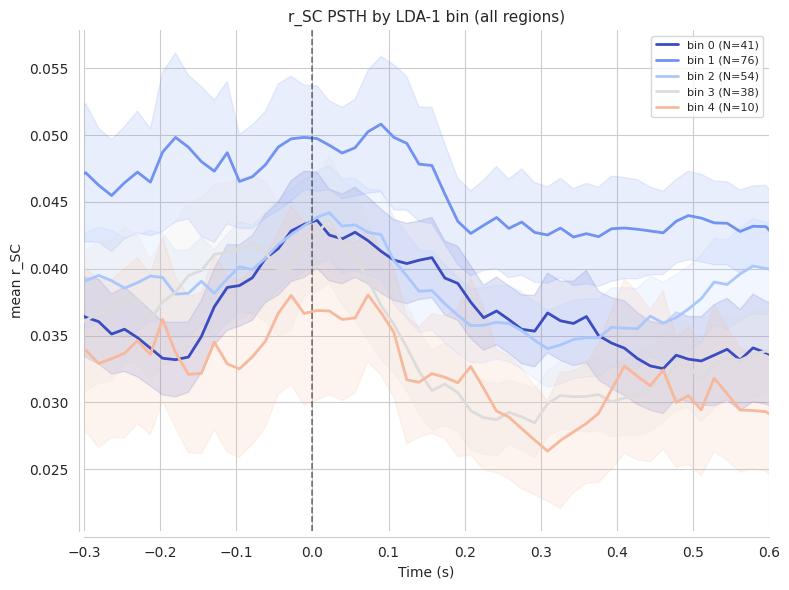

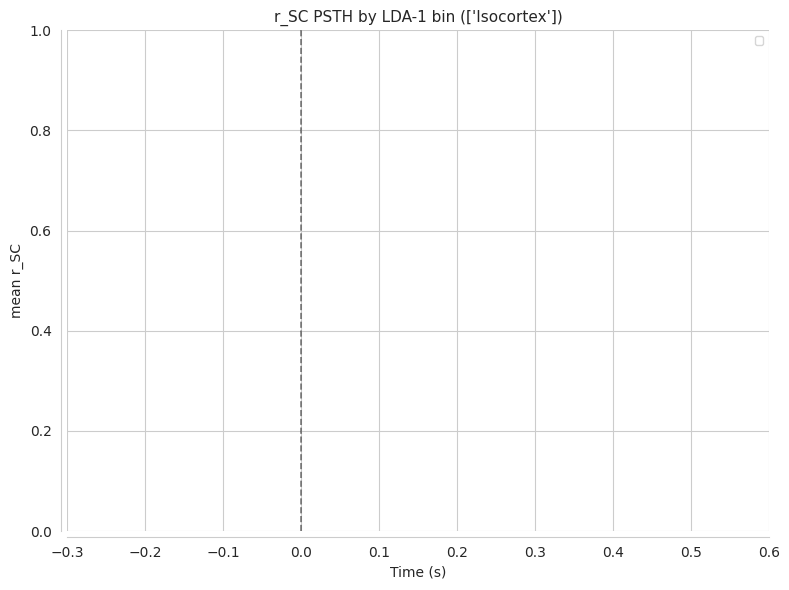

In [11]:
plot_regions(regions=None)              # averaged across all regions
plot_regions(regions=['Isocortex'])     # a specific region (edit as needed)